<a href="https://colab.research.google.com/github/OfirW3/IIoT-Network-Intrusion-Detection-Technion-ML-Course-Final-Project/blob/main/notebooks/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## === NIDS (Netork Instrusion Detection System) Project by Ofir Weit ===

##Config, Imports and Leakage Filter

In [2]:
# ==========================================
# BLOCK 1: MASTER SETUP (Imports, Config & Seeds)
# ==========================================

# --- 1. PYTHON STANDARD LIBRARIES ---
import os
import sys
import re
import gc
import time
import random
import subprocess
import importlib
from datetime import datetime

def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# --- 2. MINIMAL AUTO-INSTALLER ---
print(f"[{now()}] Verifying VM environment and installing missing packages...")

# Dictionary mapping 'import_name' -> 'pip_package_name'
required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'joblib': 'joblib',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost',
    'tensorflow': 'tensorflow',
    'torch': 'torch',
    'pytorch_tabnet': 'pytorch-tabnet'
}

# Actually execute the installation for missing packages
for import_name, pip_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"[{now()}] Missing '{import_name}'. Installing '{pip_name}' via pip...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])

# --- 3. ALL THIRD-PARTY IMPORTS ---
print(f"[{now()}] Loading libraries into memory...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# ML / DL Models
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# --- 4. CONFIGURATION ---
DATA_PATH = "/content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_combined_clean_sampled.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Model Specific Configs
N_ESTIMATORS = 100        # For RF/XGB
BATCH_SIZE = 1024         # For TabNet/NN
MAX_EPOCHS = 100          # For TabNet
LATENT_DIM = 32           # For Autoencoder
CONTAMINATION = 0.05      # For Isolation Forest

# --- 5. REPRODUCIBILITY SETUP ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds(RANDOM_STATE)

# --- 6. STATUS CHECK ---
print(f"[{now()}] === MASTER SETUP COMPLETE ===")
print(f"   -> Python: {sys.version.split()[0]}")
print(f"   -> TensorFlow: {tf.__version__}")
print(f"   -> PyTorch: {torch.__version__} | Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"   -> Data Path: {DATA_PATH}")

[2026-03-08 15:38:16] Verifying VM environment and installing missing packages...
[2026-03-08 15:38:16] Missing 'pytorch_tabnet'. Installing 'pytorch-tabnet' via pip...
[2026-03-08 15:38:21] Loading libraries into memory...
[2026-03-08 15:38:21] === MASTER SETUP COMPLETE ===
   -> Python: 3.12.12
   -> TensorFlow: 2.19.0
   -> PyTorch: 2.10.0+cu128 | Device: GPU
   -> Data Path: /content/drive/MyDrive/CIC_IIOT_2025/cic_iiot_2025_combined_clean_sampled.csv


In [3]:
# ==========================================
# BLOCK 2: DATA LOADING & MASTER LEAKAGE FILTER
# ==========================================

print(f"[{now()}] Reading CSV...")
df = pd.read_csv(DATA_PATH, low_memory=False, on_bad_lines="skip")

# --- 1. DEFINE FILTER LISTS (Must exactly match preprocess_rawcsvs.py) ---
FATAL_KEYWORDS = [
    # Identifiers & Hardware
    "mac", "port", "addr", "id", "uuid", "token", "serial", "socket", "session",
    "device", "host",
    # Specific network routing
    "ip_src", "ip_dst", "src_ip", "dst_ip",
    # Label and classification leaks
    "label", "attack", "class", "category", "status",
    # Extraneous host logging metrics
    "log"
]

TOXIC_KEYWORDS = [
    # Metadata that could be memorized by the model
    "time", "date", "timestamp", "ttl", "window", "mss", "seq", "ack"
]

SAFE_KEYWORDS = ["duration", "interval", "rate", "delta", "mean", "std", "avg", "count", "length", "size"]

# --- 2. EXECUTE FILTERING ---
feature_cols = []
dropped_examples = []
kept_examples = []

print(f"[{now()}] Filtering features...")

for c in df.columns:
    c_lower = c.lower().strip()

    # Bypass the target labels so we can use them for train/test splits later
    if c_lower in ["label1", "label2"]:
        continue

    # fatal keywords (leaking features and logs)
    is_fatal = False
    for f in FATAL_KEYWORDS:
        if f == "log" and not c_lower.startswith("log_"):
            pass # Only drop if it actually refers to the 'log_' prefix type features
        elif f in c_lower:
            # specific safe exceptions if necessary (e.g. valid identifier flags)
            if f == "id" and ("width" in c_lower or "valid" in c_lower):
                continue
            is_fatal = True
            break

    if c_lower.startswith("log_") or is_fatal:
        dropped_examples.append(c)
        continue

    # toxic keywords (time/sequence based leaks)
    is_toxic = False
    for toxic in TOXIC_KEYWORDS:
        if toxic in c_lower:
            is_toxic = True
            break

    if is_toxic:
        is_safe = False
        for safe in SAFE_KEYWORDS:
            if safe in c_lower:
                is_safe = True
                break

        if not is_safe:
            dropped_examples.append(c)
            continue

    feature_cols.append(c)
    kept_examples.append(c)

# --- 3. APPLY TO DATAFRAME ---
# Recombine the strictly filtered features with the required target columns
cols_to_keep = feature_cols + [c for c in ["label1", "label2"] if c in df.columns]
df = df[cols_to_keep]

# --- 4. REPORTING ---
print(f"[{now()}] Filtering Complete.")
print(f"   -> Original Columns: {len(dropped_examples) + len(feature_cols) + 2}")
print(f"   -> Features Kept:    {len(feature_cols)}")
print(f"   -> Features Dropped: {len(dropped_examples)}")
print(f"   -> Shape of Clean DF:{df.shape}")

[2026-03-08 15:38:21] Reading CSV...
[2026-03-08 15:38:43] Filtering features...
[2026-03-08 15:38:43] Filtering Complete.
   -> Original Columns: 95
   -> Features Kept:    59
   -> Features Dropped: 34
   -> Shape of Clean DF:(39803, 61)


In [4]:
# ==========================================
# BLOCK 3: UNIVERSAL DATA PREP (SPLIT & SCALE)
# ==========================================

print(f"\n[{now()}] Preparing Universal Datasets...")

# 1. Check if Data was loaded
if 'df' not in locals(): raise ValueError("Run Block 2 first to load and filter the data.")

# 2. Clean & Separate Targets
drop_cols = [c for c in ["label1", "label2", "target_bin", "target_multi"] if c in df.columns]
# This step exactly mimics `df_keep.apply(pd.to_numeric, errors="coerce").fillna(0)` from your sniffer preprocessor
X_raw = df.drop(columns=drop_cols).apply(pd.to_numeric, errors='coerce').fillna(0)

# Targets
y_bin = (df["label1"].astype(str).str.lower() != "benign").astype(int).values
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df["label2"].astype(str).fillna("Unknown"))

# 3. Split (Stratified on Binary Target)
X_train_raw, X_test_raw, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X_raw, y_bin, y_multi, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin
)

# 4. Scale (For Neural Nets & XGB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"[{now()}] Data Ready.")
print(f"   -> Raw Shapes: {X_train_raw.shape}")
print(f"   -> Scaled Shapes: {X_train_scaled.shape}")


[2026-03-08 15:38:44] Preparing Universal Datasets...
[2026-03-08 15:38:44] Data Ready.
   -> Raw Shapes: (31842, 59)
   -> Scaled Shapes: (31842, 59)


##First Random Forest

In [5]:
# ==========================================
# BLOCK 3.1: TRAIN RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary Random Forest...")
if 'X_train_raw' not in locals(): raise ValueError("Run Block 1.3 first.")

rf_bin = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_bin.fit(X_train_raw, y_train_bin)

print(f"[{now()}] Binary RF Saved as 'rf_bin'.")

[2026-03-08 15:38:44] Training Binary Random Forest...
[2026-03-08 15:38:51] Binary RF Saved as 'rf_bin'.


[2026-03-08 15:38:51] Evaluating Binary RF...

--- RF Binary Report ---
              precision    recall  f1-score   support

      Benign       0.81      0.98      0.89      2736
      Attack       0.99      0.88      0.93      5225

    accuracy                           0.92      7961
   macro avg       0.90      0.93      0.91      7961
weighted avg       0.93      0.92      0.92      7961



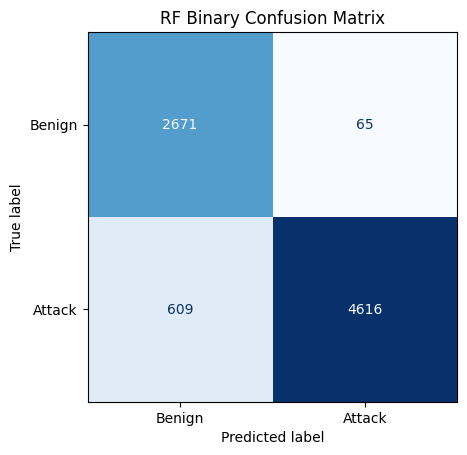

In [6]:
# ==========================================
# BLOCK 3.2: EVALUATE RANDOM FOREST (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary RF...")

preds = rf_bin.predict(X_test_raw)
print("\n--- RF Binary Report ---")
print(classification_report(y_test_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_test_bin, preds, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False)
plt.title("RF Binary Confusion Matrix")
plt.show()

In [7]:
# ==========================================
# BLOCK 3.3: TRAIN RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class Random Forest...")

rf_multi = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_multi.fit(X_train_raw, y_train_multi)

print(f"[{now()}] Multi-Class RF Saved as 'rf_multi'.")

[2026-03-08 15:38:52] Training Multi-Class Random Forest...
[2026-03-08 15:39:02] Multi-Class RF Saved as 'rf_multi'.


[2026-03-08 15:39:02] Evaluating Multi-Class RF...

--- RF Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.81      0.98      0.89      2736
       brute       0.97      0.70      0.82       192
        ddos       0.98      0.91      0.95      2171
     malware       0.94      0.90      0.92       758
        mitm       0.94      0.87      0.91       770
       recon       0.95      0.75      0.84      1051
         web       0.97      0.84      0.90       283

    accuracy                           0.90      7961
   macro avg       0.94      0.85      0.89      7961
weighted avg       0.91      0.90      0.90      7961



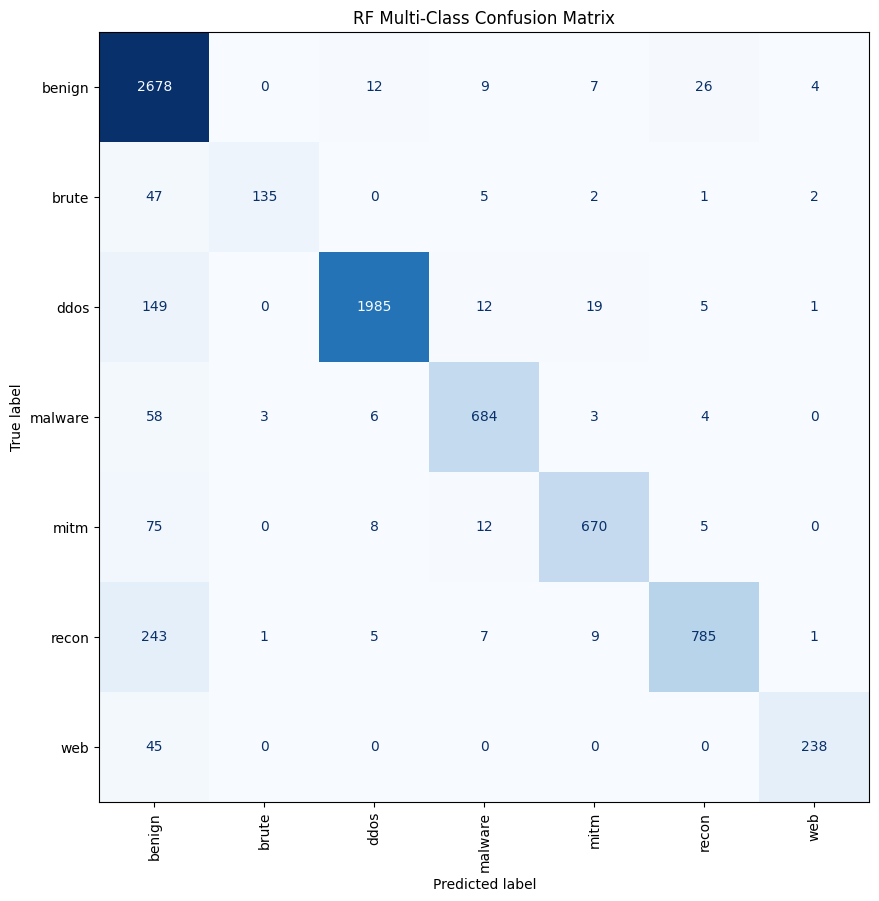

In [8]:
# ==========================================
# BLOCK 3.4: EVALUATE RANDOM FOREST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class RF...")

preds = rf_multi.predict(X_test_raw)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- RF Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Blues", colorbar=False, ax=ax)
plt.title("RF Multi-Class Confusion Matrix")
plt.show()

In [9]:
# ==========================================
# BLOCK 3.5: SAVE RANDOM FOREST MODELS
# ==========================================

print(f"[{now()}] Saving Random Forest models to Google Drive...")

# 1. Get the directory from your existing DATA_PATH
SAVE_DIR = os.path.dirname(DATA_PATH)
save_path = os.path.join(SAVE_DIR, "rf_model.pkl")

# 2. Package both models into a dictionary
rf_export = {
    "binary_model": rf_bin if 'rf_bin' in locals() else None,
    "multi_model": rf_multi if 'rf_multi' in locals() else None
}

# 3. Save to Drive
joblib.dump(rf_export, save_path)

print(f"[{now()}] Models successfully saved to:")
print(f"   -> {save_path}")

[2026-03-08 15:39:03] Saving Random Forest models to Google Drive...
[2026-03-08 15:39:08] Models successfully saved to:
   -> /content/drive/MyDrive/CIC_IIOT_2025/rf_model.pkl


##Neural Network for classifying label1 and label2

In [13]:
# ==========================================
# BLOCK 4.1: TRAIN TABNET (BINARY)
# ==========================================
print(f"[{now()}] Training Binary TabNet...")

tabnet_bin = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)

tabnet_bin.fit(
    X_train_raw.values, y_train_bin,
    eval_set=[(X_test_raw.values, y_test_bin)],
    max_epochs=20, batch_size=BATCH_SIZE, patience=5
)

print(f"[{now()}] Binary TabNet Saved as 'tabnet_bin'.")

[2026-03-08 15:45:58] Training Binary TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.44035 | val_0_auc: 0.84021 |  0:00:01s
epoch 1  | loss: 0.32833 | val_0_auc: 0.88883 |  0:00:04s
epoch 2  | loss: 0.32288 | val_0_auc: 0.91148 |  0:00:09s
epoch 3  | loss: 0.32059 | val_0_auc: 0.90259 |  0:00:11s
epoch 4  | loss: 0.31216 | val_0_auc: 0.9034  |  0:00:12s
epoch 5  | loss: 0.30919 | val_0_auc: 0.90746 |  0:00:13s
epoch 6  | loss: 0.301   | val_0_auc: 0.88515 |  0:00:15s
epoch 7  | loss: 0.27941 | val_0_auc: 0.9104  |  0:00:16s

Early stopping occurred at epoch 7 with best_epoch = 2 and best_val_0_auc = 0.91148


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-03-08 15:46:16] Binary TabNet Saved as 'tabnet_bin'.


[2026-03-08 15:46:16] Evaluating Binary TabNet...

--- TabNet Binary Report ---
              precision    recall  f1-score   support

      Benign       0.72      0.86      0.78      2736
      Attack       0.92      0.82      0.87      5225

    accuracy                           0.83      7961
   macro avg       0.82      0.84      0.82      7961
weighted avg       0.85      0.83      0.84      7961



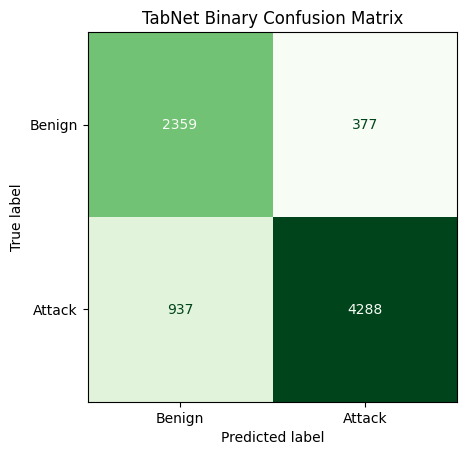

In [14]:
# ==========================================
# BLOCK 4.2: EVALUATE TABNET (BINARY)
# ==========================================
print(f"[{now()}] Evaluating Binary TabNet...")

preds = tabnet_bin.predict(X_test_raw.values)
print("\n--- TabNet Binary Report ---")
print(classification_report(y_test_bin, preds, target_names=["Benign", "Attack"]))

ConfusionMatrixDisplay.from_predictions(y_test_bin, preds, display_labels=["Benign", "Attack"], cmap="Greens", colorbar=False)
plt.title("TabNet Binary Confusion Matrix")
plt.show()

In [15]:
# ==========================================
# BLOCK 4.3: TRAIN TABNET (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class TabNet...")

tabnet_multi = TabNetClassifier(optimizer_fn=torch.optim.Adam, verbose=1)

tabnet_multi.fit(
    X_train_raw.values, y_train_multi,
    eval_set=[(X_test_raw.values, y_test_multi)],
    max_epochs=20, batch_size=BATCH_SIZE, patience=5
)
print(f"[{now()}] Multi-Class TabNet Saved as 'tabnet_multi'.")

[2026-03-08 15:46:16] Training Multi-Class TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.46425 | val_0_accuracy: 0.56915 |  0:00:01s
epoch 1  | loss: 0.88014 | val_0_accuracy: 0.60583 |  0:00:02s
epoch 2  | loss: 0.76752 | val_0_accuracy: 0.71988 |  0:00:04s
epoch 3  | loss: 0.71706 | val_0_accuracy: 0.74965 |  0:00:07s
epoch 4  | loss: 0.6961  | val_0_accuracy: 0.7685  |  0:00:08s
epoch 5  | loss: 0.68046 | val_0_accuracy: 0.78382 |  0:00:09s
epoch 6  | loss: 0.66655 | val_0_accuracy: 0.79802 |  0:00:11s
epoch 7  | loss: 0.65607 | val_0_accuracy: 0.81171 |  0:00:12s
epoch 8  | loss: 0.62538 | val_0_accuracy: 0.80065 |  0:00:13s
epoch 9  | loss: 0.60568 | val_0_accuracy: 0.81359 |  0:00:15s
epoch 10 | loss: 0.59379 | val_0_accuracy: 0.80593 |  0:00:16s
epoch 11 | loss: 0.57325 | val_0_accuracy: 0.821   |  0:00:18s
epoch 12 | loss: 0.55604 | val_0_accuracy: 0.73559 |  0:00:20s
epoch 13 | loss: 0.56245 | val_0_accuracy: 0.82163 |  0:00:21s
epoch 14 | loss: 0.55363 | val_0_accuracy: 0.73471 |  0:00:23s
epoch 15 | loss: 0.5496  | val_0_accuracy: 0.83181 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[2026-03-08 15:46:48] Multi-Class TabNet Saved as 'tabnet_multi'.


[2026-03-08 15:46:48] Evaluating Multi-Class TabNet...

--- TabNet Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.76      0.98      0.86      2736
       brute       0.46      0.11      0.18       192
        ddos       0.99      0.85      0.91      2171
     malware       0.91      0.70      0.79       758
        mitm       0.63      0.83      0.72       770
       recon       0.99      0.66      0.79      1051
         web       0.91      0.79      0.85       283

    accuracy                           0.83      7961
   macro avg       0.81      0.70      0.73      7961
weighted avg       0.85      0.83      0.83      7961



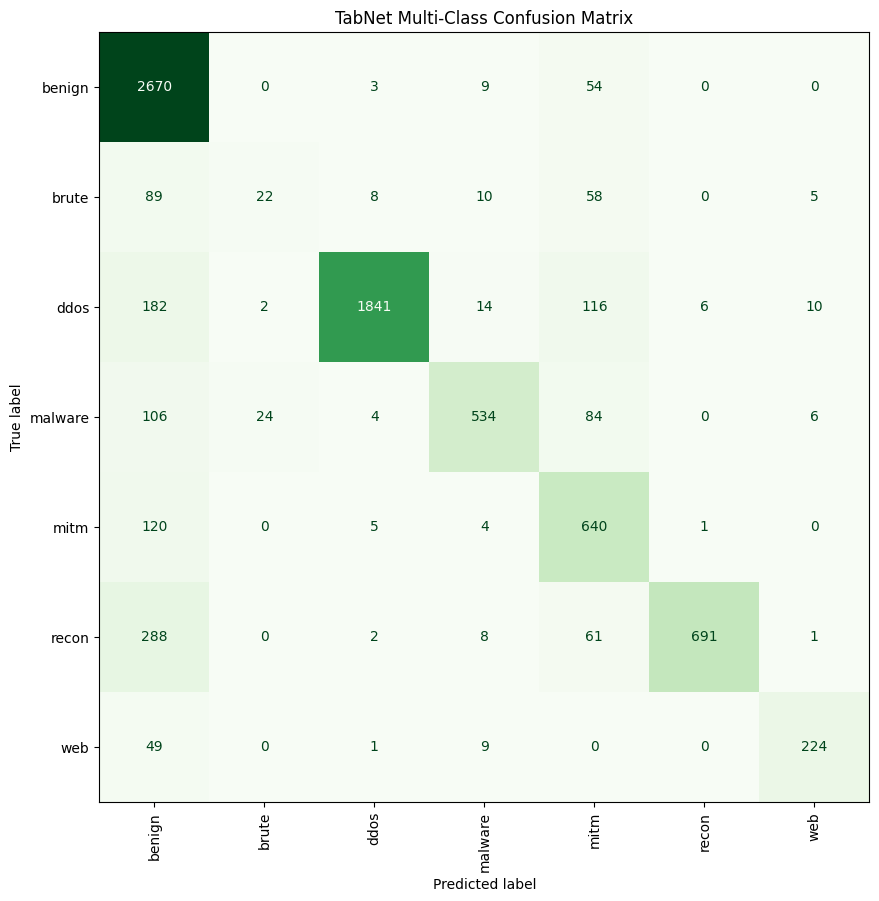

In [16]:
# ==========================================
# BLOCK 4.4: EVALUATE TABNET (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class TabNet...")

preds = tabnet_multi.predict(X_test_raw.values)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- TabNet Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Greens", colorbar=False, ax=ax)
plt.title("TabNet Multi-Class Confusion Matrix")
plt.show()

##FFNN and XGBoost combination


In [17]:
# ==========================================
# BLOCK 5.1: TRAIN AUTOENCODER (SHARED)
# ==========================================
print(f"[{now()}] Training Autoencoder...")

# Define & Train
input_dim = X_train_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(32, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='linear')(encoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=1024, verbose=0)

# Generate Features
global_encoder = encoder
X_train_enc = global_encoder.predict(X_train_scaled, verbose=0)
X_test_enc = global_encoder.predict(X_test_scaled, verbose=0)

print(f"[{now()}] Encoder Trained. Features Generated.")

[2026-03-08 15:47:20] Training Autoencoder...
[2026-03-08 15:47:29] Encoder Trained. Features Generated.


In [18]:
# ==========================================
# BLOCK 5.2: TRAIN HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary XGBoost...")

xgb_bin = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_bin.fit(X_train_enc, y_train_bin)

print(f"[{now()}] Binary XGB Saved as 'xgb_bin'.")

[2026-03-08 15:47:29] Training Binary XGBoost...
[2026-03-08 15:47:30] Binary XGB Saved as 'xgb_bin'.


In [19]:
# ==========================================
# BLOCK 5.2: TRAIN HYBRID XGBOOST (BINARY)
# ==========================================
print(f"[{now()}] Training Binary XGBoost...")

xgb_bin = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_bin.fit(X_train_enc, y_train_bin)

print(f"[{now()}] Binary XGB Saved as 'xgb_bin'.")

[2026-03-08 15:47:30] Training Binary XGBoost...
[2026-03-08 15:47:31] Binary XGB Saved as 'xgb_bin'.


In [20]:
# ==========================================
# BLOCK 5.4: TRAIN HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Training Multi-Class XGBoost...")

xgb_multi = xgb.XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
xgb_multi.fit(X_train_enc, y_train_multi)

print(f"[{now()}] Multi-Class XGB Saved as 'xgb_multi'.")

[2026-03-08 15:47:31] Training Multi-Class XGBoost...
[2026-03-08 15:47:37] Multi-Class XGB Saved as 'xgb_multi'.


[2026-03-08 15:47:37] Evaluating Multi-Class XGBoost...

--- Hybrid Multi-Class Report ---
              precision    recall  f1-score   support

      benign       0.77      0.96      0.86      2736
       brute       0.73      0.36      0.48       192
        ddos       0.98      0.89      0.93      2171
     malware       0.90      0.81      0.85       758
        mitm       0.78      0.75      0.77       770
       recon       0.94      0.71      0.81      1051
         web       0.95      0.82      0.88       283

    accuracy                           0.85      7961
   macro avg       0.86      0.76      0.80      7961
weighted avg       0.87      0.85      0.85      7961



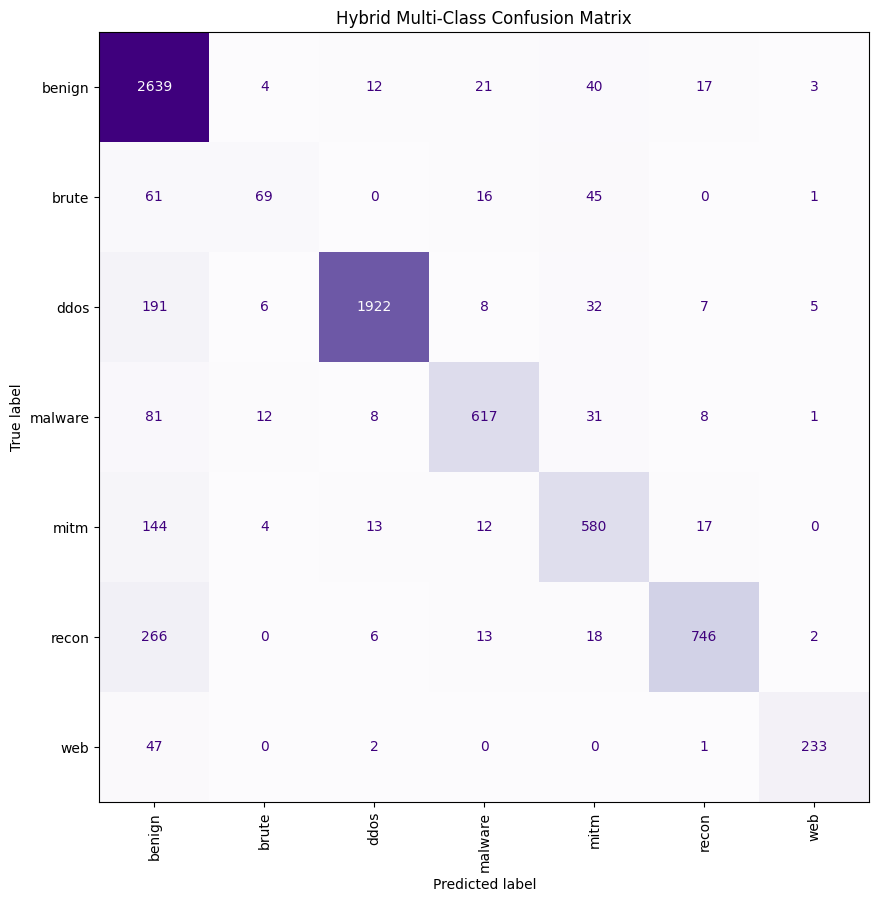

In [21]:
# ==========================================
# BLOCK 5.5: EVALUATE HYBRID XGBOOST (MULTI)
# ==========================================
print(f"[{now()}] Evaluating Multi-Class XGBoost...")

preds = xgb_multi.predict(X_test_enc)
unique_labels = sorted(set(y_test_multi) | set(preds))
target_names = [le_multi.classes_[i] for i in unique_labels]

print("\n--- Hybrid Multi-Class Report ---")
print(classification_report(y_test_multi, preds, target_names=target_names))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test_multi, preds, display_labels=target_names, xticks_rotation="vertical", cmap="Purples", colorbar=False, ax=ax)
plt.title("Hybrid Multi-Class Confusion Matrix")
plt.show()

##Anomaly detection using Sepration Forest

In [22]:
# ==========================================
# BLOCK 6.1: TRAIN ISOLATION FOREST
# ==========================================
print(f"[{now()}] Training Isolation Forest (Anomaly Detection)...")

if 'X_train_scaled' not in locals(): raise ValueError("Run Block 2.5 first.")

# 1. Filter Train Set -> Keep ONLY Benign (Class 0)
# We use the scaled data from Block 2.5
X_train_benign = X_train_scaled[y_train_bin == 0]

print(f"   -> Training on {len(X_train_benign)} Benign samples only.")

# 2. Train Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01, # Estimated % of outliers in clean data
    max_features=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

iso_forest.fit(X_train_benign)

print(f"[{now()}] Isolation Forest Saved as 'iso_forest'.")

[2026-03-08 15:47:37] Training Isolation Forest (Anomaly Detection)...
   -> Training on 10944 Benign samples only.
[2026-03-08 15:47:38] Isolation Forest Saved as 'iso_forest'.


[2026-03-08 15:47:38] Evaluating Anomaly Detection...

--- Isolation Forest Report ---
                  precision    recall  f1-score   support

 Benign (Normal)       0.43      0.99      0.60      2736
Attack (Anomaly)       0.99      0.30      0.46      5225

        accuracy                           0.54      7961
       macro avg       0.71      0.65      0.53      7961
    weighted avg       0.79      0.54      0.51      7961



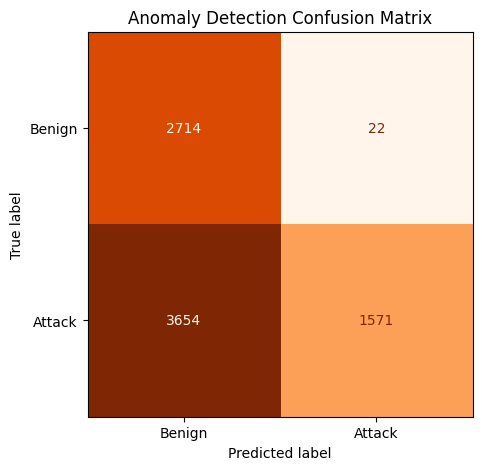

[2026-03-08 15:47:38] Stats:
   -> Total Test Samples: 7961
   -> Detected Anomalies: 1593


In [23]:
# ==========================================
# BLOCK 6.2: EVALUATE ISOLATION FOREST
# ==========================================
print(f"[{now()}] Evaluating Anomaly Detection...")

# 1. Predict (Returns: 1 = Normal, -1 = Anomaly)
preds_raw = iso_forest.predict(X_test_scaled)

# 2. Convert to Binary (0 = Benign, 1 = Attack)
# Map:  1 -> 0 (Benign)
#      -1 -> 1 (Attack)
preds_iso = np.where(preds_raw == 1, 0, 1)

# 3. Evaluation Report
print("\n--- Isolation Forest Report ---")
print(classification_report(y_test_bin, preds_iso, target_names=["Benign (Normal)", "Attack (Anomaly)"]))

# 4. Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin,
    preds_iso,
    display_labels=["Benign", "Attack"],
    cmap="Oranges",
    colorbar=False,
    ax=ax
)
plt.title("Anomaly Detection Confusion Matrix")
plt.show()

# 5. Sanity Check
print(f"[{now()}] Stats:")
print(f"   -> Total Test Samples: {len(y_test_bin)}")
print(f"   -> Detected Anomalies: {sum(preds_iso)}")

##Models's performance comparison

[2026-03-08 15:49:08] Starting Final Comparison...
[2026-03-08 15:49:08] Gathering Binary Results...
[2026-03-08 15:49:10] Gathering Multi-Class Results...

--- BINARY PERFORMANCE (Benign vs Attack) ---
                  Accuracy  Honest F1 (Macro)
Model                                        
Random Forest     0.915337           0.931960
TabNet            0.834945           0.867139
Hybrid XGBoost    0.891973           0.913079
Isolation Forest  0.538249           0.460839

--- MULTI-CLASS PERFORMANCE (Attack Types - Macro Avg) ---
                Accuracy  Honest F1 (Macro)
Model                                      
Random Forest   0.901269           0.887656
TabNet          0.831805           0.728574
Hybrid XGBoost  0.854918           0.796619


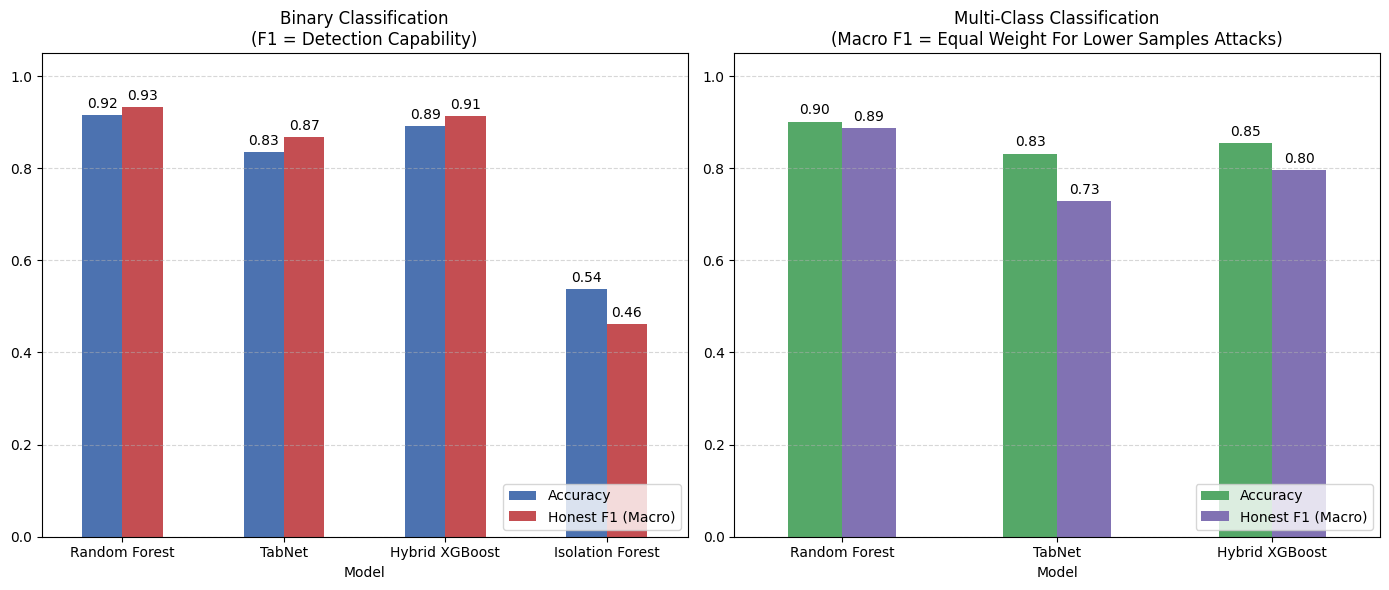

In [25]:
# ==========================================
# BLOCK 7: HONEST MODEL COMPARISON
# ==========================================
print(f"[{now()}] Starting Final Comparison...")

results_bin = []
results_multi = []

# --- 1. HONEST SCORING FUNCTION ---
def evaluate_model(name, y_true, y_pred, task="binary"):
    # Accuracy: Overall correctness
    acc = accuracy_score(y_true, y_pred)

    # F1-Score Selection:
    if task == "binary":
        # For Binary: Standard F1 (Balance of Precision/Recall for Attack class)
        f1 = f1_score(y_true, y_pred, pos_label=1)
    else:
        # For Multi-Class: MACRO F1
        # This is the "Honest" metric. It treats small attacks (Brute Force)
        # as equally important to large ones (DDoS).
        f1 = f1_score(y_true, y_pred, average='macro')

    return {"Model": name, "Accuracy": acc, "Honest F1 (Macro)": f1}

# --- 2. GATHER BINARY RESULTS (Label 1) ---
print(f"[{now()}] Gathering Binary Results...")

# Random Forest
if 'rf_bin' in locals():
    preds = rf_bin.predict(X_test_raw)
    results_bin.append(evaluate_model("Random Forest", y_test_bin, preds, task="binary"))

# TabNet
if 'tabnet_bin' in locals():
    # FIXED: Added .values to X_test_raw
    preds = tabnet_bin.predict(X_test_raw.values)
    results_bin.append(evaluate_model("TabNet", y_test_bin, preds, task="binary"))

# Hybrid XGBoost
if 'xgb_bin' in locals():
    preds = xgb_bin.predict(X_test_enc)
    results_bin.append(evaluate_model("Hybrid XGBoost", y_test_bin, preds, task="binary"))

# Isolation Forest
if 'iso_forest' in locals():
    # Convert IF predictions (-1=Anomaly/Attack, 1=Normal/Benign)
    raw_preds = iso_forest.predict(X_test_scaled)
    preds = np.where(raw_preds == 1, 0, 1)
    results_bin.append(evaluate_model("Isolation Forest", y_test_bin, preds, task="binary"))

# --- 3. GATHER MULTI-CLASS RESULTS (Label 2) ---
print(f"[{now()}] Gathering Multi-Class Results...")

# Random Forest
if 'rf_multi' in locals():
    preds = rf_multi.predict(X_test_raw)
    results_multi.append(evaluate_model("Random Forest", y_test_multi, preds, task="multi"))

# TabNet
if 'tabnet_multi' in locals():
    # FIXED: Added .values to X_test_raw
    preds = tabnet_multi.predict(X_test_raw.values)
    results_multi.append(evaluate_model("TabNet", y_test_multi, preds, task="multi"))

# Hybrid XGBoost
if 'xgb_multi' in locals():
    preds = xgb_multi.predict(X_test_enc)
    results_multi.append(evaluate_model("Hybrid XGBoost", y_test_multi, preds, task="multi"))

# --- 4. DATAFRAMES ---
df_res_bin = pd.DataFrame(results_bin).set_index("Model")
df_res_multi = pd.DataFrame(results_multi).set_index("Model")

print("\n--- BINARY PERFORMANCE (Benign vs Attack) ---")
print(df_res_bin)

print("\n--- MULTI-CLASS PERFORMANCE (Attack Types - Macro Avg) ---")
print(df_res_multi)

# --- 5. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Binary
if not df_res_bin.empty:
    df_res_bin.plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"], rot=0)
    axes[0].set_title("Binary Classification\n(F1 = Detection Capability)")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right')
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f', padding=3)

# Plot Multi-Class
if not df_res_multi.empty:
    df_res_multi.plot(kind="bar", ax=axes[1], color=["#55a868", "#8172b3"], rot=0)
    axes[1].set_title("Multi-Class Classification\n(Macro F1 = Equal Weight For Lower Samples Attacks)")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    axes[1].legend(loc='lower right')
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

##The RF model will be used due to it's best performance